In [216]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras import Sequential
from keras.layers import Dense, Dropout

In [217]:
def equation(x):
    return 5 * x ** 3 - 4 * x ** 2 - 10 * x + 7

In [218]:
x = np.linspace(-20, 20, 10000).reshape(-1, 1)
x

array([[-20.       ],
       [-19.9959996],
       [-19.9919992],
       ...,
       [ 19.9919992],
       [ 19.9959996],
       [ 20.       ]])

In [219]:
type(x)

numpy.ndarray

In [220]:
x.dtype

dtype('float64')

In [221]:
y = equation(x)
y

array([[-41393.        ],
       [-41368.40240441],
       [-41343.81453684],
       ...,
       [ 38160.37428076],
       [ 38183.68240439],
       [ 38207.        ]])

In [222]:
x.shape

(10000, 1)

In [223]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
x = x_scaler.fit_transform(x)
y = y_scaler.fit_transform(y)
x, y

(array([[0.00000000e+00],
        [1.00010001e-04],
        [2.00020002e-04],
        ...,
        [9.99799980e-01],
        [9.99899990e-01],
        [1.00000000e+00]]),
 array([[0.00000000e+00],
        [3.09015020e-04],
        [6.17907829e-04],
        ...,
        [9.99414250e-01],
        [9.99707065e-01],
        [1.00000000e+00]]))

In [224]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [225]:
len(X_train), len(X_test), len(y_train), len(y_test) 

(8000, 2000, 8000, 2000)

In [226]:
model = Sequential()
model.add(Dense(64, activation='tanh', input_shape=(1,)))
model.add(Dense(32, activation='tanh'))
model.add(Dense(16, activation='tanh'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(4, activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='linear'))

/home/sadik/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [227]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,921 (11.41 KB)

 Trainable params: 2,921 (11.41 KB)

 Non-trainable params: 0 (0.00 B)

In [228]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
    jit_compile=False
)

In [229]:
result = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=500,
    validation_data=(X_test, y_test)
)

Epoch 1/500


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0144 - mae: 0.0821 - val_loss: 0.0060 - val_mae: 0.0657
Epoch 2/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0062 - mae: 0.0662 - val_loss: 0.0060 - val_mae: 0.0656
Epoch 3/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0061 - mae: 0.0660 - val_loss: 0.0061 - val_mae: 0.0642
Epoch 4/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - mae: 0.0645 - val_loss: 0.0058 - val_mae: 0.0615
Epoch 5/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0051 - mae: 0.0593 - val_loss: 0.0041 - val_mae: 0.0514
Epoch 6/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0029 - mae: 0.0421 - val_loss: 0.0014 - val_mae: 0.0286
Epoch 7/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.6859e-04 - mae: 0.0181 - val_loss: 1.5908e-04 - val_mae: 0.0083
Epoch 8/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9387e-05 - mae: 0.0059 - val_loss: 2.7593e-05 - val_mae: 0.0041
Epoch 9/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [230]:
model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0093e-07 - mae: 4.5803e-04  


[3.009259330610803e-07, 0.00045802738168276846]

In [234]:
i = 0
while i != 3:
    num = float(input("Enter a number: "))

    nums = np.array([[num]], dtype=np.float32)
    nums_scaled = x_scaler.transform(nums)

    actual = equation(num)

    pred_scaled = model.predict(nums_scaled, verbose=0)
    pred = y_scaler.inverse_transform(pred_scaled)[0][0]

    print(f"Actual : {actual}\nPredict : {pred}\n")

    i += 1

Actual : 223.0
Predict : 249.68519592285156

Actual : 1456.0
Predict : 1497.8997802734375

Actual : -2.0
Predict : 21.971494674682617



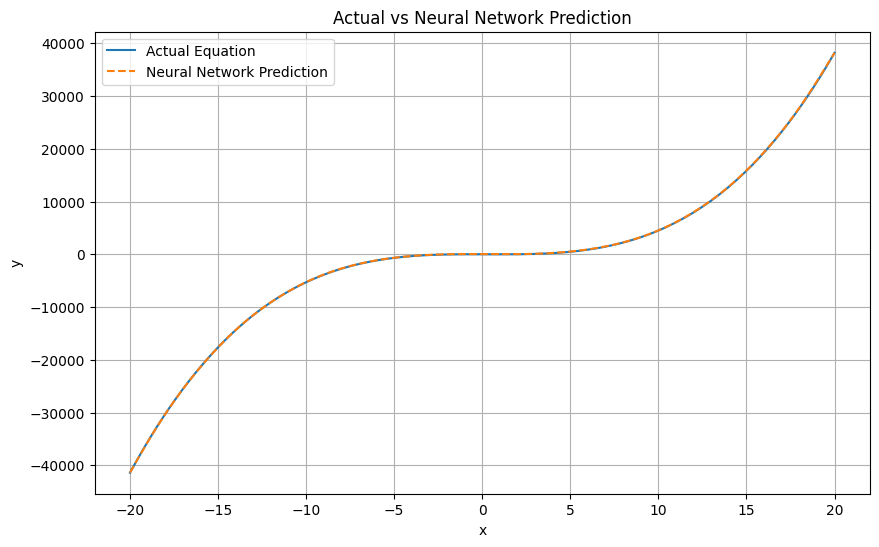

In [232]:
import matplotlib.pyplot as plt

# Generate points for plotting
x_plot = np.linspace(-20, 20, 1000).reshape(-1, 1)

# Scale inputs
x_plot_scaled = x_scaler.transform(x_plot)

# Predict
y_pred_scaled = model.predict(x_plot_scaled, verbose=0)

# Inverse transform predictions
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Actual values
y_actual = equation(x_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_actual, label="Actual Equation")
plt.plot(x_plot, y_pred, '--', label="Neural Network Prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual vs Neural Network Prediction")
plt.legend()
plt.grid(True)
plt.show()

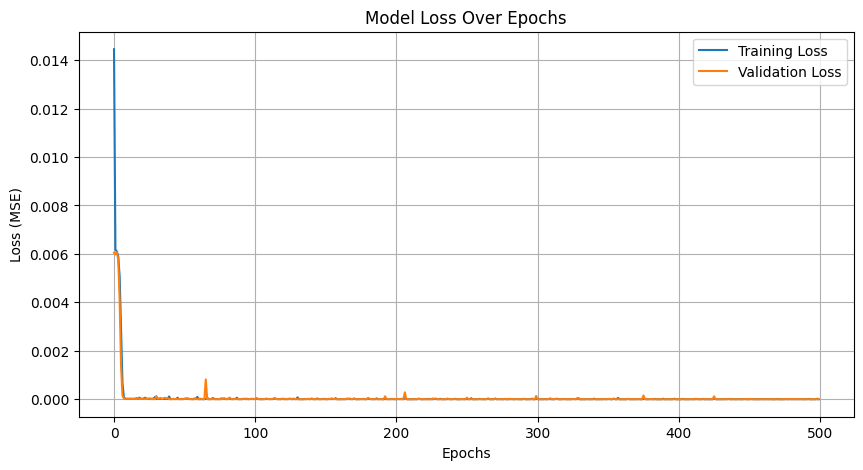

In [233]:
import matplotlib.pyplot as plt

# Plot loss
plt.figure(figsize=(10, 5))

plt.plot(result.history['loss'], label='Training Loss')
plt.plot(result.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()